In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
plt.rcParams['axes.labelsize']=16
plt.rcParams['xtick.labelsize']=14
plt.rcParams['ytick.labelsize']=14
plt.rcParams['legend.fontsize']=13

In [5]:
import statsmodels.api as sm 
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

In [6]:
S=pd.read_csv('/Users/comedesolere/Desktop/Centrale/TD MDS/synthetic_ARMA.csv')

S.head()

,S1,S2
0,-0.004463,0.576042
1,-0.009984,1.046018
2,-0.009714,0.630641
3,-0.010939,0.108865
4,-0.023265,0.383786


In [7]:
s1,s2=S['S1'].values,S['S2'].values

We select the best ARIMA model to approximize the s1 series by applying the box-jenkins method

Text(0.5, 0, '$t$')

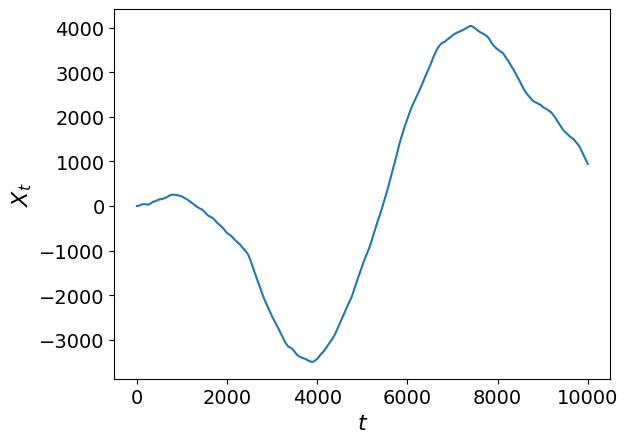

In [8]:
plt.plot(s1)
plt.ylabel(r'$X_t$')
plt.xlabel(r'$t$')


Text(0.5, 0, '$lags$')

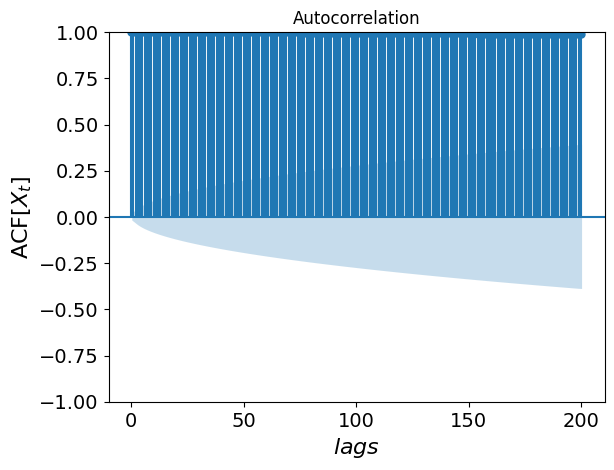

In [9]:
sm.graphics.tsa.plot_acf(s1,lags=200)
plt.ylabel('ACF[$X_t$]')
plt.xlabel(r'$lags$')

In [10]:
adfuller(s1)

(-2.664564367283874,
 0.08037345140926583,
 5,
 9994,
 {'1%': -3.4310044907347454,
  '5%': -2.8618292459530794,
  '10%': -2.566923960483154},
 -63471.618890449696)

In [11]:
s1=np.diff(s1)

Text(0.5, 0, '$t$')

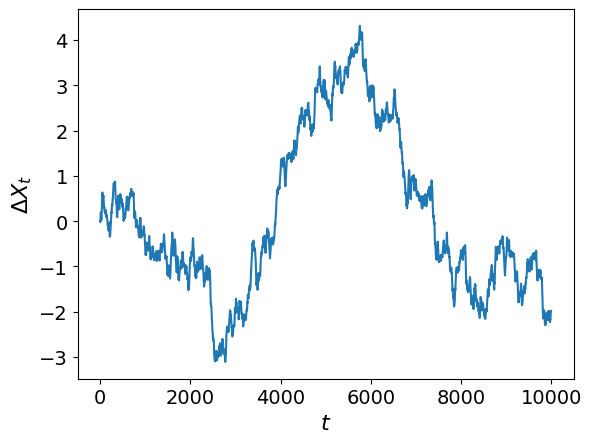

In [12]:
plt.plot(s1)
plt.ylabel(r'$\Delta X_t$')
plt.xlabel(r'$t$')

Text(0.5, 0, '$lags$')

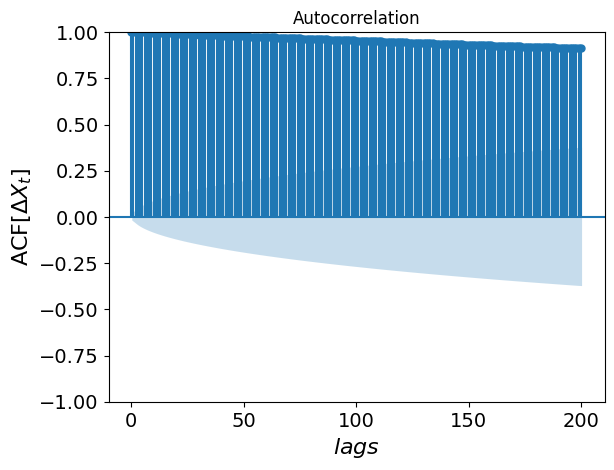

In [13]:
sm.graphics.tsa.plot_acf(s1,lags=200)
plt.ylabel('ACF[$\Delta X_t$]')
plt.xlabel(r'$lags$')

In [14]:
adfuller(s1)

(-1.233472498800838,
 0.6590335468124892,
 4,
 9994,
 {'1%': -3.4310044907347454,
  '5%': -2.8618292459530794,
  '10%': -2.566923960483154},
 -63459.6437861537)

In [15]:
s1=np.diff(s1)

Text(0.5, 0, '$t$')

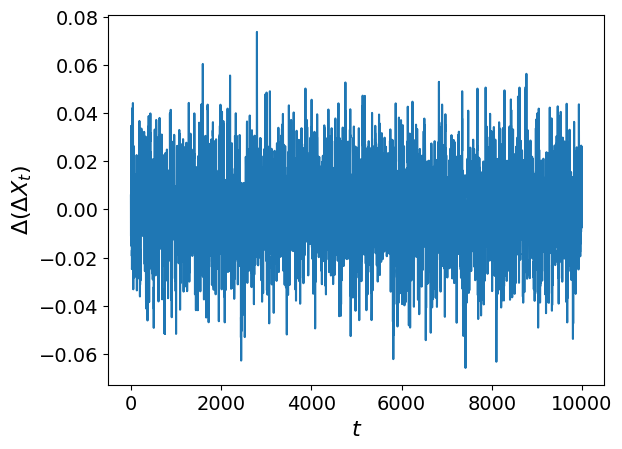

In [16]:
plt.plot(s1)
plt.ylabel(r'$\Delta (\Delta X_t)$')
plt.xlabel(r'$t$')

Text(0.5, 0, '$lags$')

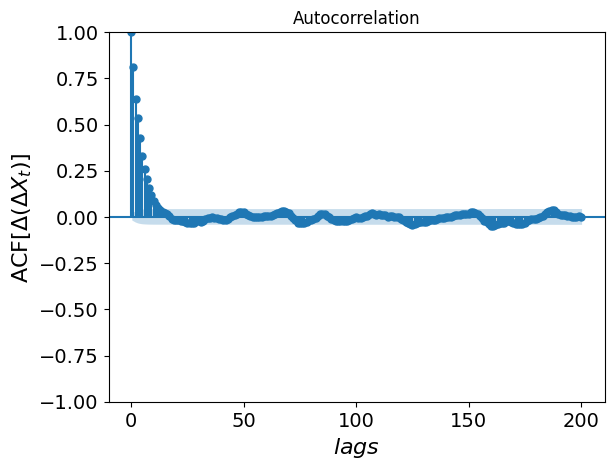

In [17]:
sm.graphics.tsa.plot_acf(s1,lags=200)
plt.ylabel('ACF[$\Delta (\Delta X_t)$]')
plt.xlabel(r'$lags$')

In [18]:
adfuller(s1)

(-29.20993446692401,
 0.0,
 3,
 9994,
 {'1%': -3.4310044907347454,
  '5%': -2.8618292459530794,
  '10%': -2.566923960483154},
 -63452.76165510001)

After 2 differentiation of the series, the adfuller allow us to reject the null-hypothesis of non stationarity.

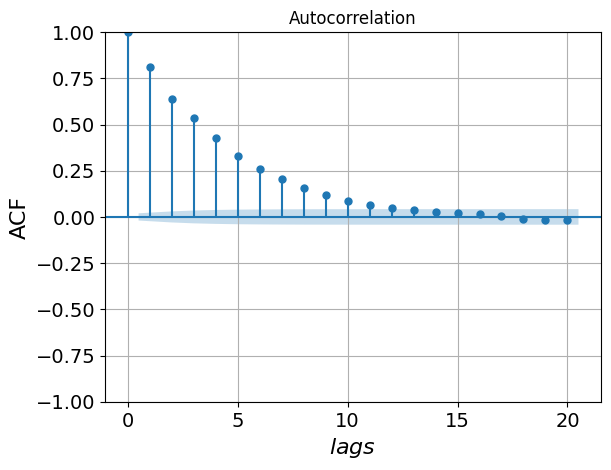

In [19]:
sm.graphics.tsa.plot_acf(s1,lags=20)
plt.ylabel('ACF')
plt.xlabel(r'$lags$')
plt.grid()

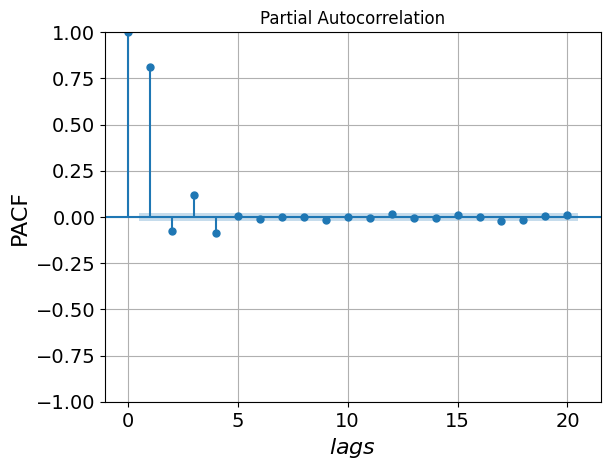

In [20]:
sm.graphics.tsa.plot_pacf(s1,lags=20)
plt.ylabel('PACF')
plt.xlabel(r'$lags$')
plt.grid()

The PACF graph implies that there could be an AR(4) component in the model, we count 11 lags with the ACF which may be a lot to try an MA(11) component. So we will try with smaller models.

In [21]:
models=[(4,0),(1,1),(2,1),(1,2),(2,2)]

In [22]:
M={}
for p,q in models:
    ft= ARIMA(s1,order=(p,0,q)).fit()
    M[p,q]=ft

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [23]:
M[(2,1)].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 9998
Model:                 ARIMA(2, 0, 1)   Log Likelihood               31825.190
Date:                Tue, 17 Jun 2025   AIC                         -63640.380
Time:                        15:28:21   BIC                         -63604.330
Sample:                             0   HQIC                        -63628.177
                               - 9998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.001     -0.401      0.689      -0.001       0.001
ar.L1          0.2445      0.042      5.838      0.000       0.162       0.327
ar.L2          0.4263      0.036     11.825      0.000       0.356       0.497
ma.L1          0.6723      0.038     17.785      0.000       0.598       0.746
sigma2         0.0001   1.43e-06     70.291      0.000    9.77e-05       0.000
===================================================================================
Ljung-Box (L1) (Q):                   4.35   Jarque-Bera (JB):                 0.91
Prob(Q):                              0.04   Prob(JB):                         0.63
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
AIC=pd.DataFrame([((p,q),ft.aic) for (p,q),ft in M.items()],columns=['model','AIC'])

AIC

,model,AIC
0,"(4, 0)",-63698.956085
1,"(1, 1)",-63507.870989
2,"(2, 1)",-63640.380222
3,"(1, 2)",-63652.905305
4,"(2, 2)",-63676.352739


In [25]:
AIC=AIC.assign(dAIC=AIC.AIC - AIC.AIC.min())

AIC.sort_values('AIC')

,model,AIC,dAIC
0,"(4, 0)",-63698.956085,0.000000
4,"(2, 2)",-63676.352739,22.603346
3,"(1, 2)",-63652.905305,46.050780
2,"(2, 1)",-63640.380222,58.575863
1,"(1, 1)",-63507.870989,191.085096


The comparison of the AIC between candidates picks the AR(4) model as best model

In [26]:
# fit model with no constant
model_ar4_no_const=ARIMA(s1,order=(4,0,0),trend='n')
results_ar4_no_const=model_ar4_no_const.fit()
results_ar4_no_const.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 9998
Model:                 ARIMA(4, 0, 0)   Log Likelihood               31855.405
Date:                Tue, 17 Jun 2025   AIC                         -63700.810
Time:                        15:28:22   BIC                         -63664.759
Sample:                             0   HQIC                        -63688.607
                               - 9998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8957      0.010     90.046      0.000       0.876       0.915
ar.L2         -0.1960      0.013    -15.074      0.000      -0.222      -0.171
ar.L3          0.1954      0.013     14.733      0.000       0.169       0.221
ar.L4         -0.0873      0.010     -8.854      0.000      -0.107      -0.068
sigma2      9.999e-05   1.42e-06     70.204      0.000    9.72e-05       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.99
Prob(Q):                              0.96   Prob(JB):                         0.61
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.56   Kurtosis:                         2.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

0 is in the confidence intervall of the constant in the AR(4) model. We compare the model with the same without constant

In [27]:
results_ar4_no_const.aic - M[(4,0)].aic

-1.853466300002765

the model without constant is indeed better

In [28]:
r = results_ar4_no_const.resid

Text(0.5, 0, '$lags$')

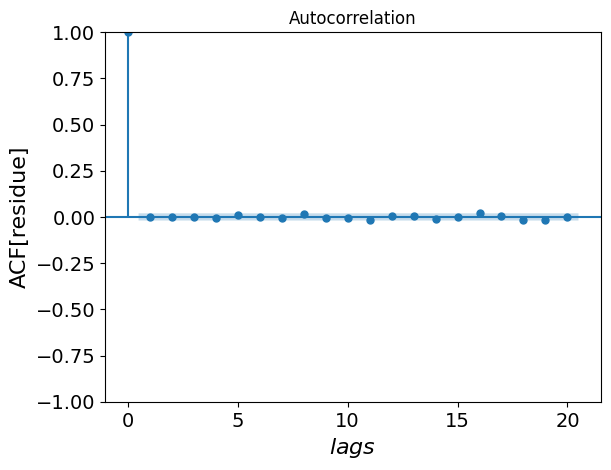

In [29]:
sm.graphics.tsa.plot_acf(r,lags=20)
plt.ylabel('ACF[residue]')
plt.xlabel(r'$lags$')

the residues seem uncorrelated and the ljungbox model confirms it so the model selected seems to be proper.

In [33]:
acorr_ljungbox(r,lags=(p+q+10),model_df=p+q,return_df=True)

,lb_stat,lb_pvalue
10,4.664923,0.912409
